## Assignment 9

### Student Performance Prediction

#### Linear Regression

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'D:\SSA\self\Python\Practice Data File\Student_Performance.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (10000, 6)

First 5 rows:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [4]:
print('Data Types:')
print(df.dtypes)

Data Types:
Hours Studied                        int64
Previous Scores                      int64
Extracurricular Activities          object
Sleep Hours                          int64
Sample Question Papers Practiced     int64
Performance Index                    int64
dtype: object


In [5]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
print('Missing Values per Column:')
print(df.isnull().sum())

Missing Values per Column:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [7]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [8]:
df = df.rename(columns={
    'Hours Studied'                   : 'Hours_Studied',
    'Previous Scores'                 : 'Previous_Scores',
    'Extracurricular Activities'       : 'Extracurricular',
    'Sleep Hours'                     : 'Sleep_Hours',
    'Sample Question Papers Practiced': 'Papers_Practiced',
    'Performance Index'               : 'Performance_Score'
})

print('Renamed columns:', df.columns.tolist())

Renamed columns: ['Hours_Studied', 'Previous_Scores', 'Extracurricular', 'Sleep_Hours', 'Papers_Practiced', 'Performance_Score']


In [9]:
X = df[['Hours_Studied', 'Previous_Scores', 'Extracurricular',
         'Sleep_Hours', 'Papers_Practiced']]

y = df['Performance_Score']

print('Features (X) shape:', X.shape)
print('Target  (y) shape :', y.shape)
print('\nFeature columns:', X.columns.tolist())
print('Target column   : Performance_Score')

Features (X) shape: (10000, 5)
Target  (y) shape : (10000,)

Feature columns: ['Hours_Studied', 'Previous_Scores', 'Extracurricular', 'Sleep_Hours', 'Papers_Practiced']
Target column   : Performance_Score


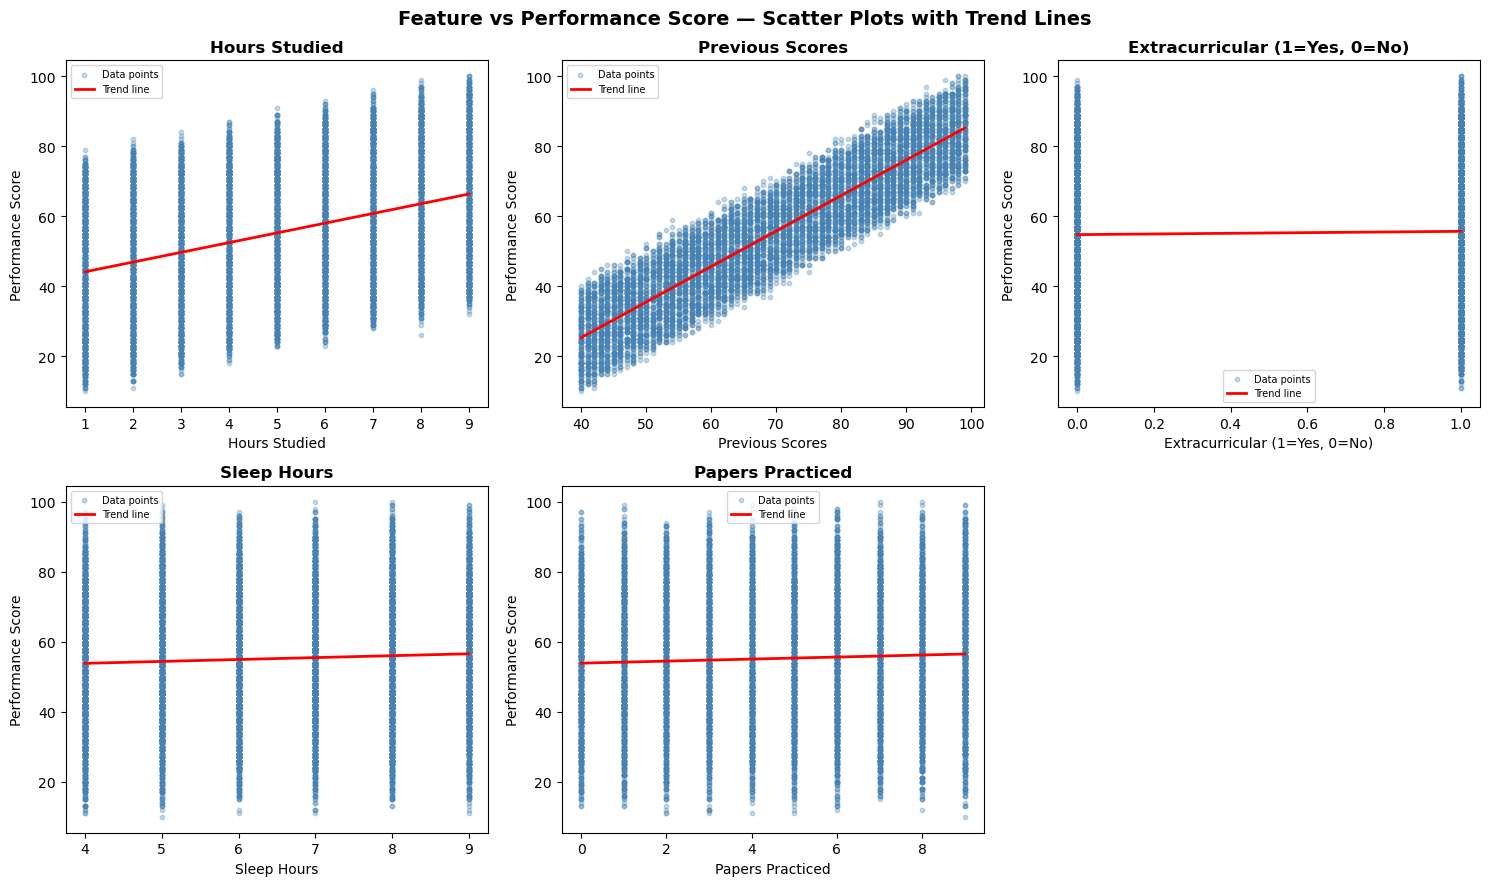

In [10]:
features    = ['Hours_Studied', 'Previous_Scores', 'Extracurricular',
               'Sleep_Hours', 'Papers_Practiced']
feat_labels = ['Hours Studied', 'Previous Scores', 'Extracurricular (1=Yes, 0=No)',
               'Sleep Hours', 'Papers Practiced']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Feature vs Performance Score — Scatter Plots with Trend Lines',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for i, (feat, label) in enumerate(zip(features, feat_labels)):

    ax = axes_flat[i]


    ax.scatter(df[feat], df['Performance_Score'],
               color='steelblue', alpha=0.3, s=10, label='Data points')


    m, b = np.polyfit(df[feat], df['Performance_Score'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, color='red', linewidth=2, label='Trend line')

    ax.set_title(f'{label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Performance Score')
    ax.legend(fontsize=7)


axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()


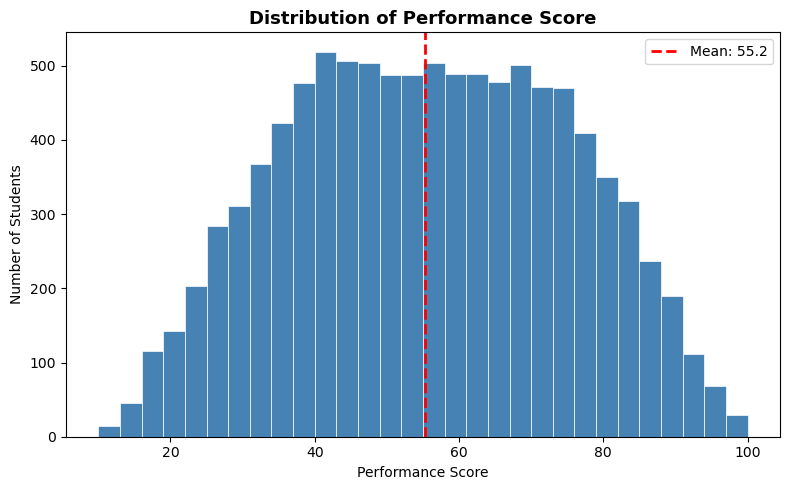

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df['Performance_Score'], bins=30, color='steelblue',
         edgecolor='white', linewidth=0.5)
plt.axvline(df['Performance_Score'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {df["Performance_Score"].mean():.1f}')
plt.title('Distribution of Performance Score', fontsize=13, fontweight='bold')
plt.xlabel('Performance Score')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
df.corr()

,Hours_Studied,Previous_Scores,Extracurricular,Sleep_Hours,Papers_Practiced,Performance_Score
Hours_Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous_Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep_Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Papers_Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance_Score,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


Correlation with Performance Score:
Previous_Scores     0.915189
Hours_Studied       0.373730
Sleep_Hours         0.048106
Papers_Practiced    0.043268
Extracurricular     0.024525


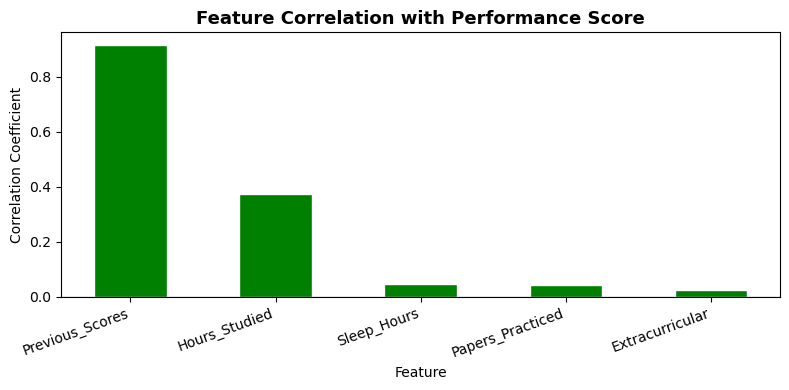

In [13]:
corr = df.corr()['Performance_Score'].drop('Performance_Score').sort_values(ascending=False)
print('Correlation with Performance Score:')
print(corr.to_string())

plt.figure(figsize=(8, 4))
colors = ['green' if v > 0 else 'red' for v in corr.values]
plt.bar(corr.index, corr.values, color=colors, edgecolor='white', width=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Performance Score', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.3,
    random_state = 42
)

print('Training set size :', X_train.shape[0], 'rows')
print('Testing  set size :', X_test.shape[0],  'rows')
print(f'\nTotal: {X_train.shape[0] + X_test.shape[0]} rows')

Training set size : 7000 rows
Testing  set size : 3000 rows

Total: 10000 rows


##### Performance_Score = b0 + b1×Hours + b2×PrevScore + b3×Extra + b4×Sleep + b5×Papers

In [18]:
model = LinearRegression()


model.fit(X_train, y_train)

print('✅ Model trained successfully!')
print('\nModel Intercept (b0):', round(model.intercept_, 4))
print('\nModel Coefficients:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature:<22}: {coef:+.4f}')

✅ Model trained successfully!

Model Intercept (b0): -33.8365

Model Coefficients:
  Hours_Studied         : +2.8590
  Previous_Scores       : +1.0155
  Extracurricular       : +0.5817
  Sleep_Hours           : +0.4797
  Papers_Practiced      : +0.1904


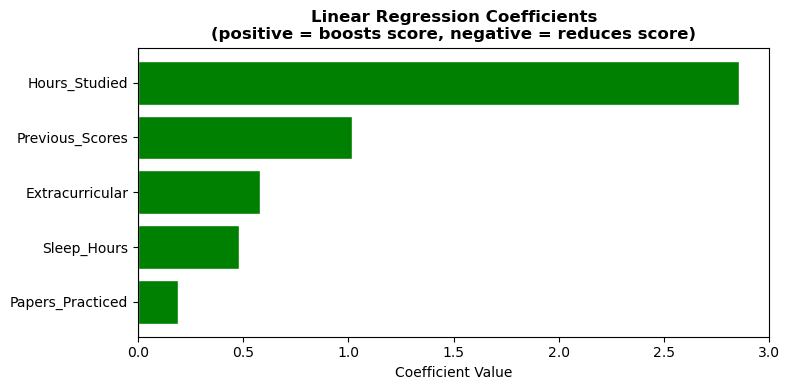

In [19]:
coef_series = pd.Series(model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4))
colors = ['green' if v > 0 else 'red' for v in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients\n(positive = boosts score, negative = reduces score)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [20]:
y_pred = model.predict(X_test)


comparison = pd.DataFrame({
    'Actual Score'   : y_test.values[:10],
    'Predicted Score': np.round(y_pred[:10], 2)
})
comparison['Difference'] = (comparison['Predicted Score'] - comparison['Actual Score']).round(2)

print('First 10 Predictions vs Actual Values:')
print(comparison.to_string(index=False))

First 10 Predictions vs Actual Values:
 Actual Score  Predicted Score  Difference
           51            54.75        3.75
           20            22.62        2.62
           46            47.94        1.94
           28            31.34        3.34
           41            43.06        2.06
           59            59.12        0.12
           48            45.92       -2.08
           87            86.46       -0.54
           37            37.77        0.77
           73            72.06       -0.94


#### Evaluate The Model
    - By using following 3 key metrics:
        - R² Score — how well the model explains variance (closer to 1.0 = better)
        - MSE — Mean Squared Error (average squared difference between actual & predicted)
        - RMSE — Root Mean Squared Error (same unit as the target variable)
        

In [21]:
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test.values - y_pred))

print('=' * 40)
print('     MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  R² Score : {r2:.4f}   ({r2*100:.2f}% variance explained)')
print(f'  MSE      : {mse:.4f}')
print(f'  RMSE     : {rmse:.4f}  (avg error ±{rmse:.2f} points)')
print(f'  MAE      : {mae:.4f}  (avg absolute error)')
print('=' * 40)
if r2 > 0.85:
    print('  Excellent fit!')
elif r2 > 0.70:
    print('  Good fit!')
else:
    print('  Moderate fit — consider adding more features.')

     MODEL EVALUATION RESULTS
  R² Score : 0.9890   (98.90% variance explained)
  MSE      : 4.0666
  RMSE     : 2.0166  (avg error ±2.02 points)
  MAE      : 1.6090  (avg absolute error)
  Excellent fit!


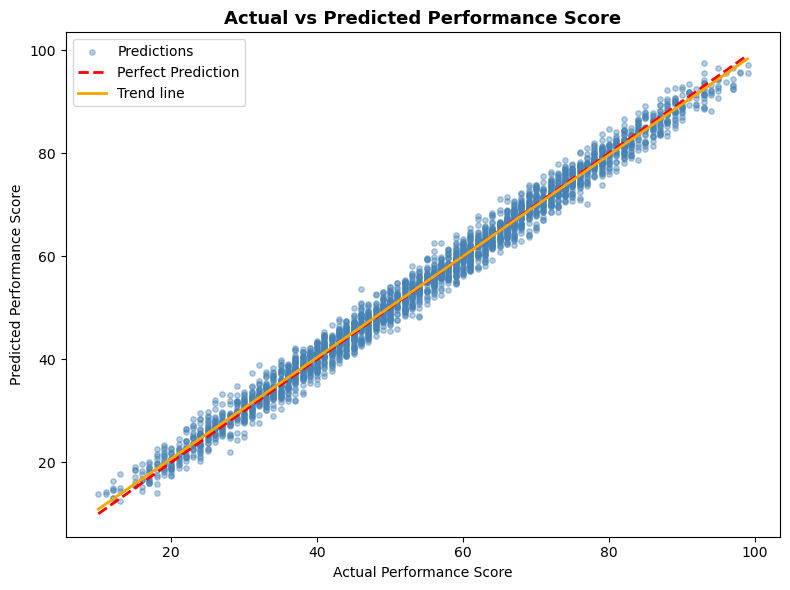

The closer the blue dots are to the red dashed line, the better the predictions.


In [22]:
# Plot 1: Actual vs Predicted (Scatter with trend line)

plt.figure(figsize=(8, 6))


plt.scatter(y_test, y_pred, color='steelblue', alpha=0.4, s=15, label='Predictions')


min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')


m, b = np.polyfit(y_test, y_pred, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, m * x_line + b, color='orange', linewidth=2, label='Trend line')

plt.title('Actual vs Predicted Performance Score', fontsize=13, fontweight='bold')
plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted Performance Score')
plt.legend()
plt.tight_layout()
plt.show()
print('The closer the blue dots are to the red dashed line, the better the predictions.')

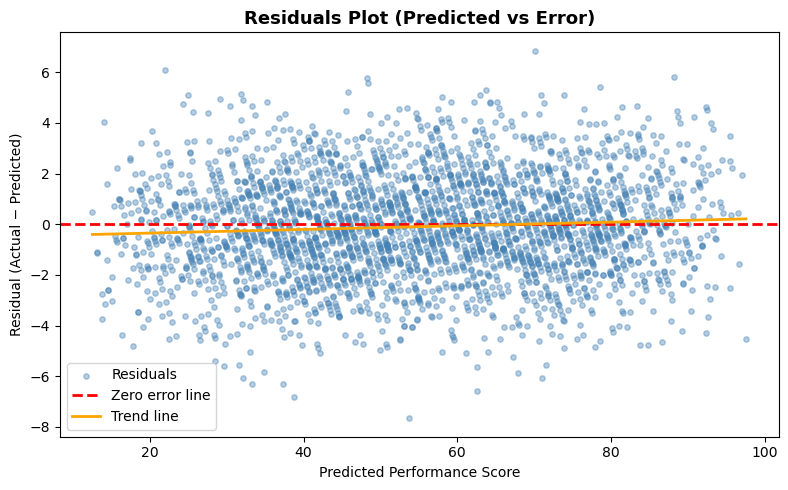

Residuals should be randomly scattered around 0. A flat trend = good model.


In [23]:
# Plot 2: Residuals Plot (errors)

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))


plt.scatter(y_pred, residuals, color='steelblue', alpha=0.4, s=15, label='Residuals')


plt.axhline(0, color='red', linewidth=2, linestyle='--', label='Zero error line')


m, b = np.polyfit(y_pred, residuals, 1)
x_line = np.linspace(y_pred.min(), y_pred.max(), 100)
plt.plot(x_line, m * x_line + b, color='orange', linewidth=2, label='Trend line')

plt.title('Residuals Plot (Predicted vs Error)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Performance Score')
plt.ylabel('Residual (Actual − Predicted)')
plt.legend()
plt.tight_layout()
plt.show()
print('Residuals should be randomly scattered around 0. A flat trend = good model.')

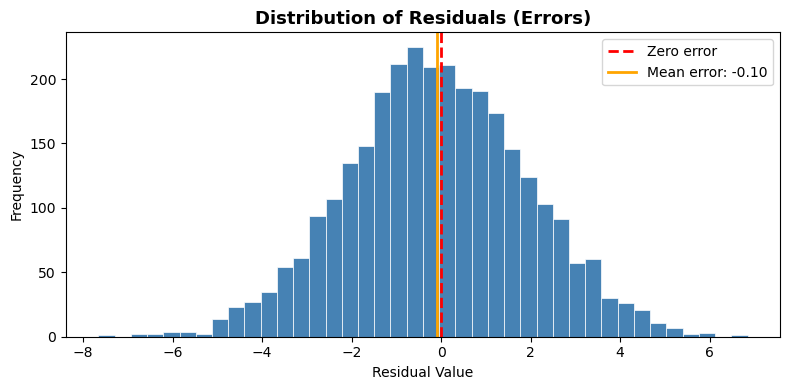

A bell-shaped curve centered near 0 means the model errors are normally distributed — a good sign!


In [24]:
# Plot 3: Residual distribution histogram

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(0, color='red', linewidth=2, linestyle='--', label='Zero error')
plt.axvline(residuals.mean(), color='orange', linewidth=2, linestyle='-',
            label=f'Mean error: {residuals.mean():.2f}')
plt.title('Distribution of Residuals (Errors)', fontsize=13, fontweight='bold')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
print('A bell-shaped curve centered near 0 means the model errors are normally distributed — a good sign!')

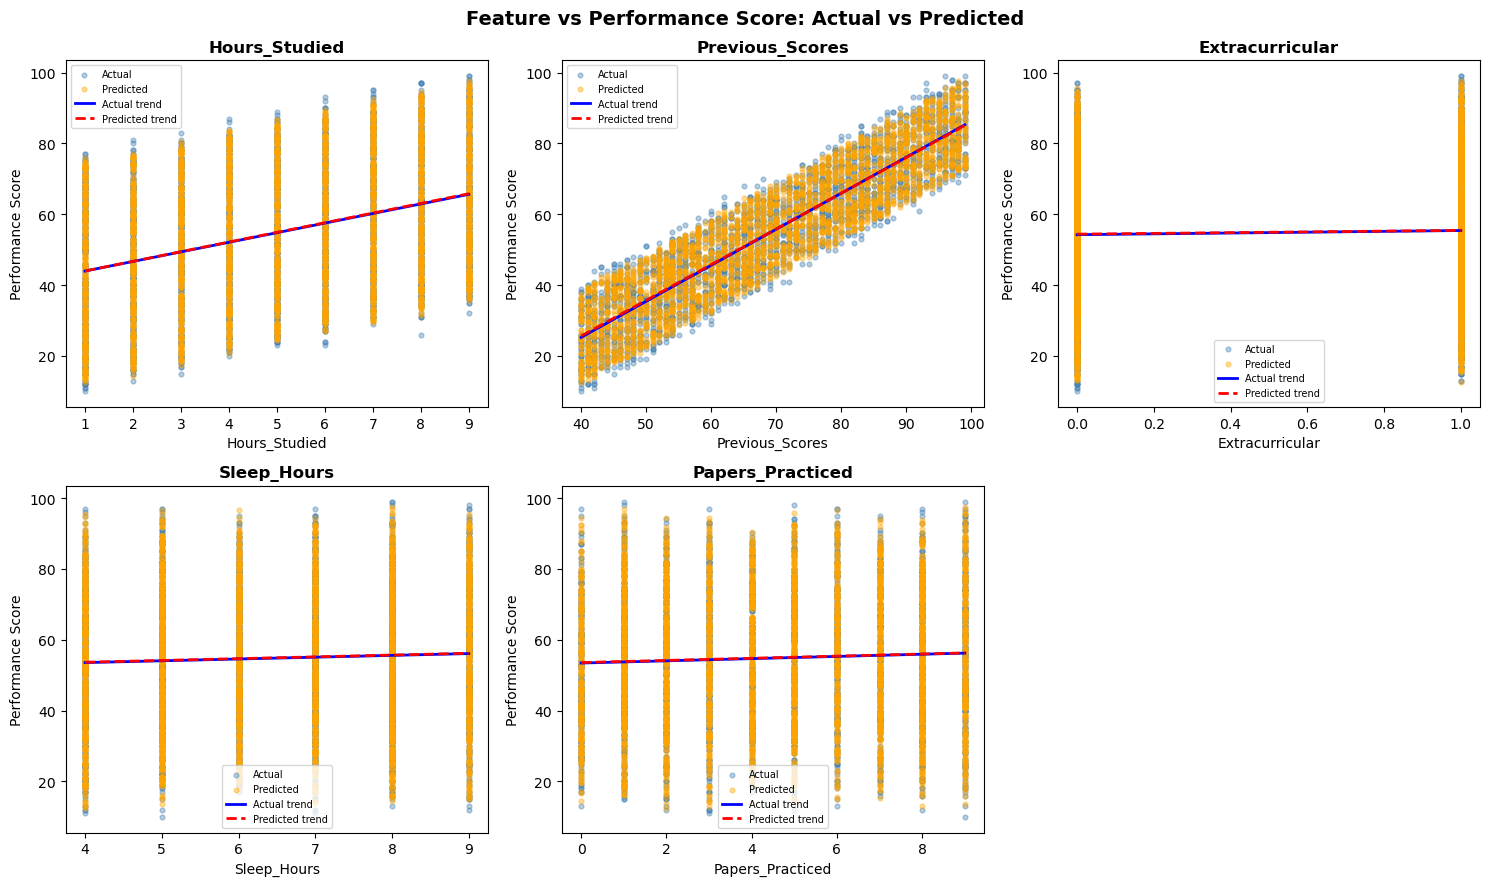

In [25]:
# Plot 4: Scatter — each feature vs actual vs predicted

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Feature vs Performance Score: Actual vs Predicted',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for i, feat in enumerate(X.columns):
    ax = axes_flat[i]

    
    ax.scatter(X_test_reset[feat], y_test_reset,
               color='steelblue', alpha=0.4, s=12, label='Actual')

    
    ax.scatter(X_test_reset[feat], y_pred,
               color='orange', alpha=0.4, s=12, label='Predicted')

    
    m1, b1 = np.polyfit(X_test_reset[feat], y_test_reset, 1)
    x_line = np.linspace(X_test_reset[feat].min(), X_test_reset[feat].max(), 100)
    ax.plot(x_line, m1*x_line + b1, color='blue', linewidth=2, label='Actual trend')

    
    m2, b2 = np.polyfit(X_test_reset[feat], y_pred, 1)
    ax.plot(x_line, m2*x_line + b2, color='red', linewidth=2, linestyle='--', label='Predicted trend')

    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Performance Score')
    ax.legend(fontsize=7)

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.show()

In [29]:
new_student = pd.DataFrame({
    'Hours_Studied'   : [7],
    'Previous_Scores' : [85],
    'Extracurricular' : [1],
    'Sleep_Hours'     : [7],
    'Papers_Practiced': [5]
})

print('New Student Details:')
print(new_student.to_string(index=False))


predicted_score = model.predict(new_student)

print(f'\nPredicted Performance Score: {predicted_score[0]:.2f}')

New Student Details:
 Hours_Studied  Previous_Scores  Extracurricular  Sleep_Hours  Papers_Practiced
             7               85                1            7                 5

Predicted Performance Score: 77.39


Multiple Student Predictions:
        Student  Hours_Studied  Previous_Scores  Extracurricular  Sleep_Hours  Papers_Practiced  Predicted_Score
   Weak Student              2               45                0            5                 1            20.17
Average Student              5               70                1            7                 4            56.25
 Strong Student              9               95                1            8                 8            94.31


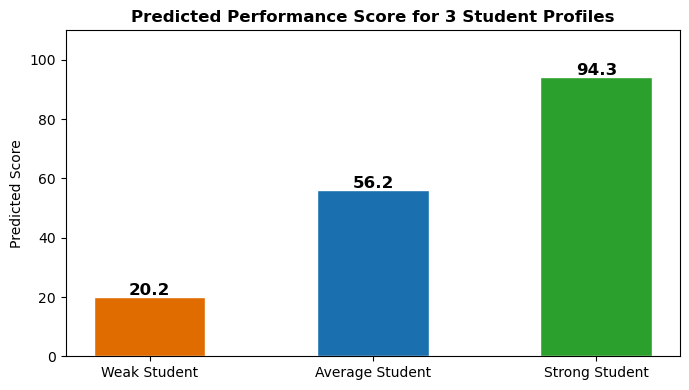

In [30]:
new_students = pd.DataFrame({
    'Hours_Studied'   : [2,  5,  9],
    'Previous_Scores' : [45, 70, 95],
    'Extracurricular' : [0,  1,  1],
    'Sleep_Hours'     : [5,  7,  8],
    'Papers_Practiced': [1,  4,  8]
})

predictions = model.predict(new_students)

new_students['Predicted_Score'] = np.round(predictions, 2)
new_students['Student']         = ['Weak Student', 'Average Student', 'Strong Student']

print('Multiple Student Predictions:')
print(new_students[['Student','Hours_Studied','Previous_Scores',
                     'Extracurricular','Sleep_Hours',
                     'Papers_Practiced','Predicted_Score']].to_string(index=False))


plt.figure(figsize=(7, 4))
bars = plt.bar(new_students['Student'], new_students['Predicted_Score'],
               color=['#e06c00','#1a6faf','#2ca02c'], edgecolor='white', width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', fontweight='bold', fontsize=12)
plt.title('Predicted Performance Score for 3 Student Profiles',
          fontsize=12, fontweight='bold')
plt.ylabel('Predicted Score')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [32]:
# Compare Train vs Test Performance (Overfitting Check)

y_train_pred = model.predict(X_train)

r2_train  = r2_score(y_train, y_train_pred)
r2_test   = r2_score(y_test,  y_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_pred)

print('='*45)
print(f'  {"Metric":<10}  {"Train Set":>12}  {"Test Set":>12}')
print('-'*45)
print(f'  {"R² Score":<10}  {r2_train:>12.4f}  {r2_test:>12.4f}')
print(f'  {"MSE":<10}  {mse_train:>12.4f}  {mse_test:>12.4f}')
print(f'  {"RMSE":<10}  {np.sqrt(mse_train):>12.4f}  {np.sqrt(mse_test):>12.4f}')
print('='*45)

diff = abs(r2_train - r2_test)
if diff < 0.02:
    print('\nTrain and Test scores are very close — No overfitting!')
elif diff < 0.05:
    print('\nSlight difference — model generalizes well.')
else:
    print('\nLarge gap — possible overfitting. Consider regularization.')

  Metric         Train Set      Test Set
---------------------------------------------
  R² Score          0.9886        0.9890
  MSE               4.1935        4.0666
  RMSE              2.0478        2.0166

Train and Test scores are very close — No overfitting!


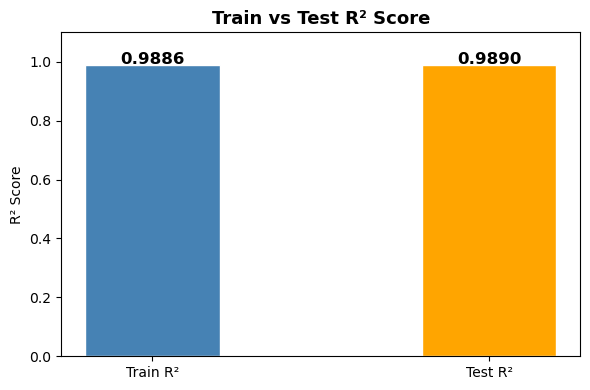

In [33]:
# Train vs Test R² comparison

plt.figure(figsize=(6, 4))
bars = plt.bar(['Train R²', 'Test R²'], [r2_train, r2_test],
               color=['steelblue', 'orange'], edgecolor='white', width=0.4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=12)
plt.title('Train vs Test R² Score', fontsize=13, fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [34]:
joblib.dump(model, 'student_performance_model.pkl')

['student_performance_model.pkl']

In [35]:
loaded_model = joblib.load('student_performance_model.pkl')

test_student = pd.DataFrame({
    'Hours_Studied'   : [6],
    'Previous_Scores' : [80],
    'Extracurricular' : [1],
    'Sleep_Hours'     : [7],
    'Papers_Practiced': [4]
})

score = loaded_model.predict(test_student)[0]
print(f'\nLoaded model prediction for test student: {score:.2f}')


Loaded model prediction for test student: 69.26


## Key Findings:
    * Previous Scores is the strongest predictor of Performance Score
    * Hours Studied is the second most important feature
    * Extracurricular Activities has the smallest impact
    * The model achieves high R² — it explains most of the variance in student performance